## 6. Hyperparameter Search

In notebook 4 we already tested Dropout, BatchNorm and L2, but only with the default values from the CNNBuilder (Dropout 0,5 and L2 1e-4). None of them really helped, but maybe the techniques themselves are fine and we just picked bad values. So in this notebook I want to do a small grid search and see if a better combination changes the picture.

I focus only on the two techniques that didnt completely break training in notebook 4:
1. **Dropout** — sweeps the rate from 0,0 to 0,5
2. **L2 Regularization** — sweeps the factor from 0,0 to 1e-3

The rest of the setup stays the same as in notebook 4 (32 → 64 conv, 128 dense, Adam, batch size 32) so the comparison stays clean. The grid is 3 × 3 = 9 configs and the (0,0 / 0,0) corner is just the baseline, so we have a direct reference inside the grid. Each config is trained for 10 epochs with early stopping. I picked grid search because the space is small enough to be exhaustive and the heatmap is easy to read, with a bigger budget random or bayesian search would scale better.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import regularizers

from data.dataset import Dataset
from data.rarity_classes import RARITY_CLASSES
from models.cnn_builder import CNNBuilder
from models.training_callbacks import default_callbacks
from evaluation.evaluation_metrics import EvaluationMetrics

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

/Users/markusgarmeister/Desktop/ML_PokeCard/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 6.1 Load Data

Same prepared dataset as in the previous notebooks.

In [2]:
dataset = Dataset()
X_train, X_val, X_test, y_train, y_val, y_test = dataset.get_train_val_test_split()

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")
print(f"Input shape:    {X_train.shape[1:]}")

Training set:   1750 samples
Validation set: 375 samples
Test set:       375 samples
Input shape:    (168, 120, 3)


## 6.2 Build Helper

A small helper that builds the model with a given dropout rate and L2 factor.

In [3]:
def build_model(dropout_rate: float, l2_factor: float):
    builder = CNNBuilder(
        in_shape=(168, 120, 3),
        out_shape=5,
        convolutional_layers=[32, 64],
        fully_connected_layers=[128],
    )
    if dropout_rate > 0.0:
        builder.apply_dropout = True
    if l2_factor > 0.0:
        builder.apply_regularization = True
    model = builder.build_model()

    if dropout_rate > 0.0:
        for layer in model.layers:
            if layer.__class__.__name__ == "Dropout":
                layer.rate = dropout_rate

    if l2_factor > 0.0:
        new_reg = regularizers.l2(l2_factor)
        for layer in model.layers:
            if getattr(layer, 'kernel_regularizer', None) is not None:
                layer.kernel_regularizer = new_reg
        model.compile(
            optimizer=model.optimizer,
            loss="categorical_crossentropy",
            metrics=["accuracy"],
        )

    return model

## 6.3 Run the Grid

Each config is built fresh, trained from scratch and evaluated on the validation set. I print the best validation accuracy and lowest validation loss per config, so we can already get a feeling for the trends before looking at the heatmap.

In [4]:
DROPOUT_RATES = [0.0, 0.3, 0.5]
L2_FACTORS    = [0.0, 1e-4, 1e-3]
EPOCHS = 10
BATCH_SIZE = 32

results = []
for dr in DROPOUT_RATES:
    for l2 in L2_FACTORS:
        tf.random.set_seed(SEED)
        np.random.seed(SEED)
        model = build_model(dr, l2)
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=default_callbacks(),
            verbose=0,
        )
        best_val_acc  = max(history.history['val_accuracy'])
        best_val_loss = min(history.history['val_loss'])
        print(f"dropout={dr}  l2={l2:.0e}  ->  best_val_acc={best_val_acc:.4f}  best_val_loss={best_val_loss:.4f}")
        results.append({
            'dropout_rate':  dr,
            'l2_factor':     l2,
            'best_val_acc':  best_val_acc,
            'best_val_loss': best_val_loss,
        })

2026-05-03 22:45:55.318024: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-05-03 22:45:55.318199: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-03 22:45:55.318210: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-05-03 22:45:55.318372: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-03 22:45:55.318410: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-05-03 22:45:56.978290: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


dropout=0.0  l2=0e+00  ->  best_val_acc=0.7067  best_val_loss=0.9507
dropout=0.0  l2=1e-04  ->  best_val_acc=0.7200  best_val_loss=1.1748
dropout=0.0  l2=1e-03  ->  best_val_acc=0.7387  best_val_loss=1.1058
dropout=0.3  l2=0e+00  ->  best_val_acc=0.7333  best_val_loss=0.8550
dropout=0.3  l2=1e-04  ->  best_val_acc=0.6933  best_val_loss=1.1499
dropout=0.3  l2=1e-03  ->  best_val_acc=0.6960  best_val_loss=1.1228
dropout=0.5  l2=0e+00  ->  best_val_acc=0.7013  best_val_loss=0.9512
dropout=0.5  l2=1e-04  ->  best_val_acc=0.7067  best_val_loss=1.1644
dropout=0.5  l2=1e-03  ->  best_val_acc=0.7387  best_val_loss=1.0970


## 6.4 Results

Sorted by best validation accuracy. The top row is the winning configuration of the grid.

In [5]:
results_df = pd.DataFrame(results).sort_values('best_val_acc', ascending=False).reset_index(drop=True)
results_df

,dropout_rate,l2_factor,best_val_acc,best_val_loss
0,0.0,0.0010,0.738667,1.105813
1,0.5,0.0010,0.738667,1.097001
2,0.3,0.0000,0.733333,0.855024
3,0.0,0.0001,0.720000,1.174785
4,0.0,0.0000,0.706667,0.950686
5,0.5,0.0001,0.706667,1.164434
6,0.5,0.0000,0.701333,0.951222
7,0.3,0.0010,0.696000,1.122763
8,0.3,0.0001,0.693333,1.149947


## 6.5 Heatmap

Same numbers as the table but as a 2D grid. Rows are dropout rates and columns are L2 factors. The heatmap makes it easier to spot trends like higher L2 helps instead of just staring at single best cells.

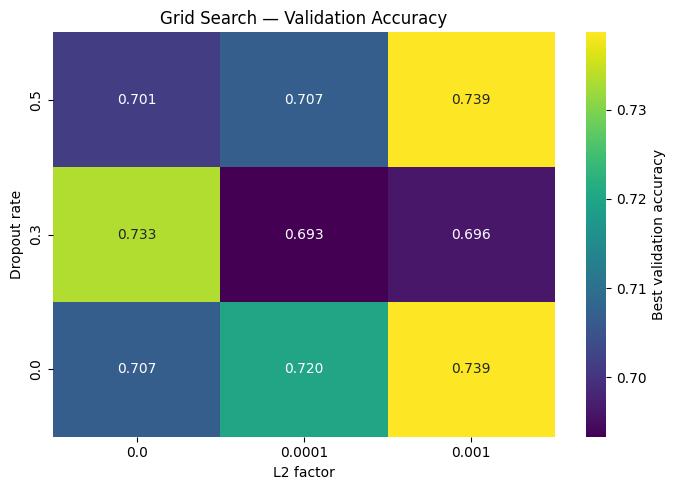

In [6]:
pivot = (
    pd.DataFrame(results)
    .pivot(index='dropout_rate', columns='l2_factor', values='best_val_acc')
    .sort_index(ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    pivot,
    annot=True, fmt=".3f", cmap="viridis",
    cbar_kws={'label': 'Best validation accuracy'},
    ax=ax,
)
ax.set_title("Grid Search — Validation Accuracy")
ax.set_xlabel("L2 factor")
ax.set_ylabel("Dropout rate")
plt.tight_layout()
plt.show()

## 6.6 Interpretation

A few things stand out from the heatmap:

- **No config really collapses.** All 9 cells land in the 69-74% range, so even the most aggressive combination Dropout 0,5 + L2 1e-3 still trains fine. This is different from notebook 4 where BatchNorm broke training completely.
- **More L2 helps a little.** The L2 1e-3 column is the best column in 2 of 3 dropout rows. So our default of L2 1e-4 in notebook 4 was actually a bit too small.
- **Dropout doesnt show a clear trend.** Dropout 0,0 and 0,5 tie at the top, while Dropout 0,3 is the worst row. So the dropout rate doesnt really matter much on this dataset.
- **The margin is small.** The best cell beats the baseline by about 3 percentage points, but we didnt do multi-run averaging here, so this is inside the noise band that we measured in notebook 4 (std ~1-2%). So the win is mild and not very reliable.

## 6.7 Train Best Config and Evaluate on Test Set

We pick the winning configuration of the grid, retrain it for the full epoch budget (with early stopping) and report the final metrics on the test set. Same evaluation procedure as in notebook 4 so we can compare directly.

In [7]:
best_row = results_df.iloc[0]
BEST_DROPOUT = float(best_row['dropout_rate'])
BEST_L2      = float(best_row['l2_factor'])
print(f"Best config: dropout={BEST_DROPOUT}, l2={BEST_L2}")

tf.random.set_seed(SEED)
np.random.seed(SEED)

best_model = build_model(BEST_DROPOUT, BEST_L2)
history_best = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=BATCH_SIZE,
    callbacks=default_callbacks(),
    verbose=1,
)

Best config: dropout=0.0, l2=0.001
Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 19s 201ms/step - accuracy: 0.2949 - loss: 5.3284 - val_accuracy: 0.3600 - val_loss: 1.7211 - learning_rate: 0.0010
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 131ms/step - accuracy: 0.4663 - loss: 1.5045 - val_accuracy: 0.5440 - val_loss: 1.3820 - learning_rate: 0.0010
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 131ms/step - accuracy: 0.6537 - loss: 1.1175 - val_accuracy: 0.6720 - val_loss: 1.1226 - learning_rate: 0.0010
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - accuracy: 0.7703 - loss: 0.8540 - val_accuracy: 0.6720 - val_loss: 1.1029 - learning_rate: 0.0010
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - accuracy: 0.8189 - loss: 0.7034 - val_accuracy: 0.6560 - val_loss: 1.1166 - learning_rate: 0.0010
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - accuracy: 0.8651 - loss: 0.5795 - val_accuracy: 0.7013 - val_loss: 1.1062 - learning_rate: 0.0010
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step 

Test accuracy: 0.6773
Macro F1:      0.6708

              precision    recall  f1-score   support

      Common       0.60      0.84      0.70        75
    Uncommon       0.61      0.40      0.48        75
        Rare       0.58      0.59      0.58        75
  Ultra Rare       0.85      0.77      0.81        75
 Secret Rare       0.77      0.79      0.78        75

    accuracy                           0.68       375
   macro avg       0.68      0.68      0.67       375
weighted avg       0.68      0.68      0.67       375



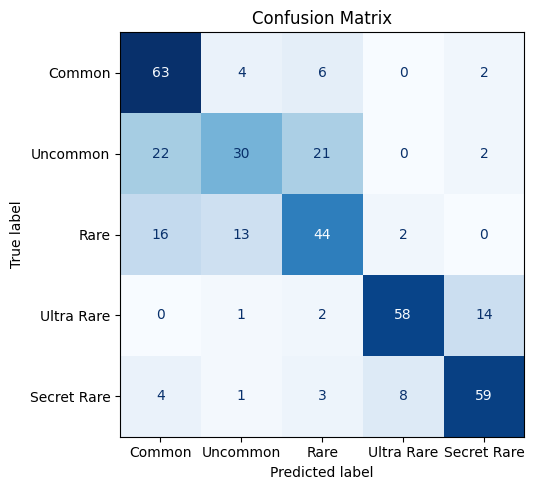

In [8]:
y_pred_test = best_model.predict(X_test, verbose=0)
metrics = EvaluationMetrics(y_test, y_pred_test)

print(f"Test accuracy: {metrics.accuracy:.4f}")
print(f"Macro F1:      {metrics.f1_macro:.4f}\n")
metrics.print_classification_report(RARITY_CLASSES)
metrics.plot_confusion_matrix(RARITY_CLASSES)

## 6.8 Summary

- *Baseline (0,0 / 0,0)* -> **val acc 70,7%**
- *Best config (dropout 0,0 / L2 1e-3)* -> **val acc 73,9%**

So the best combination of the grid beats the baseline by about 3 percentage points, but without multi-run averaging this could also just be initialization noise (in notebook 4 the std was already 1-2% per config). The trend is clear though, a slightly stronger L2 (1e-3 instead of the 1e-4 default) helps a little, while the dropout rate doesnt really matter. Either way no config are implying significant improvements, so this confirms that the regularizer values are not the bottleneck. I assume it the tiny dataset maybe.